In [16]:
import fitsio, numpy as np, healpy as hp

In [17]:
X = fitsio.read('/project/kadrlica/dhayaa/SPT/2500d_cluster_sample_fiducial_cosmology.fits')

In [22]:
X = hp.read_map('/project/kadrlica/dhayaa/ACTDR6/mask_act_dr6_lensing_v1_healpix_nside_4096_baseline.fits')

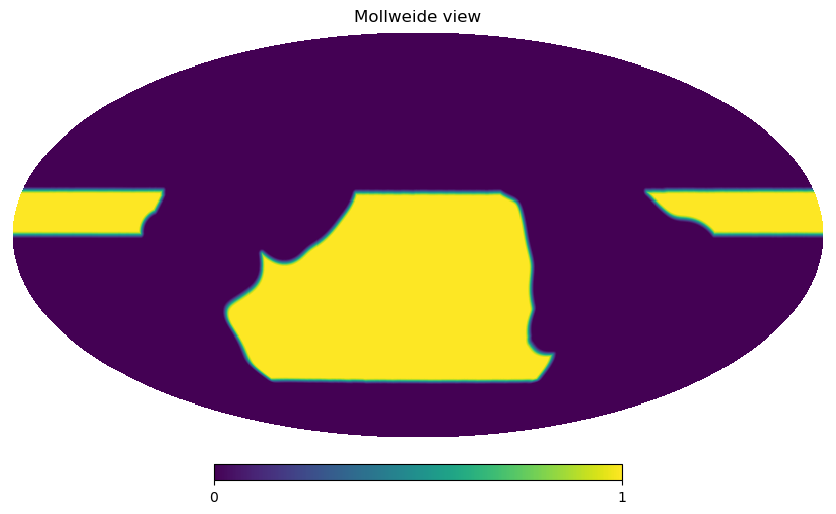

In [23]:
hp.mollview(X)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skyproj, healpy as hp, h5py, fitsio
from scipy import stats
import pandas as pd
from tqdm import tqdm
import skyproj

import os
if os.environ['USER'] == 'dhayaa':
    os.environ['PATH'] = f"{os.environ['PATH']}:/software/texlive-2023/bin/x86_64-linux"

plt.rcParams["axes.linewidth"]  = 1.0
plt.rcParams["xtick.major.size"]  = 10
plt.rcParams["xtick.minor.size"]  = 5
plt.rcParams["ytick.major.size"]  = 10
plt.rcParams["ytick.minor.size"]  = 5
plt.rcParams["xtick.direction"]  = "in"
plt.rcParams["ytick.direction"]  = "in"
plt.rcParams["legend.frameon"] = 'False'
plt.rcParams['figure.figsize'] = [10, 10]
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=17)

if os.environ['USER'] == 'dhayaa':
    os.environ['PATH'] = f"{os.environ['PATH']}:/software/texlive-2022-el8-x86_64/bin/x86_64-linux/"


COLORS = ["f07167","219ebc","ffba0a","c767ac","59a270"]
COLORS = ['#' + c if c[0] != '#' else c for c in COLORS ]

# Update the default prop_cycle
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=COLORS)


from matplotlib.colors import LinearSegmentedColormap, ListedColormap
custom_cmap = LinearSegmentedColormap.from_list(None, [COLORS[1], 'white', COLORS[3]])
# custom_cmap.set_bad(color = 'k', alpha = 0.02)
def discretize_cmap(cmap, num_colors): return ListedColormap([cmap(i / (num_colors - 1)) for i in range(num_colors)])

In [2]:
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18
import astropy.units as u


def rank_ordered_catalog_match(
    ra_1,
    dec_1,
    obs_1,
    redshift_1,
    ra_2,
    dec_2,
    obs_2,
    redshift_2,
    max_projected_radius=1.5,
    max_redshift_difference=0.1,
):
    """
    Rank-ordered, one-to-one matching between two catalogs.

    Catalog 1 is processed in descending order of ``obs_1``. For each
    Catalog-1 object, the function finds all currently unmatched Catalog-2
    objects satisfying

        |z_1 - z_2| <= max_redshift_difference

    and

        R_projected <= max_projected_radius.

    Among the valid candidates, the object with the largest ``obs_2`` is
    selected. Once selected, that Catalog-2 object is removed from the pool
    of possible counterparts.

    The projected separation is computed as

        R_projected = theta * D_A(z_1),

    where theta is the angular separation and D_A is the Planck18 angular
    diameter distance evaluated at the Catalog-1 object's redshift.

    Parameters
    ----------
    ra_1, dec_1 : array-like
        Right ascension and declination of Catalog 1 in degrees.

    obs_1 : array-like
        Selection observable for Catalog 1. Objects are processed from
        highest to lowest value.

    redshift_1 : array-like
        Redshifts of Catalog 1.

    ra_2, dec_2 : array-like
        Right ascension and declination of Catalog 2 in degrees.

    obs_2 : array-like
        Selection observable for Catalog 2. When multiple valid counterparts
        exist, the object with the largest value is selected.

    redshift_2 : array-like
        Redshifts of Catalog 2.

    max_projected_radius : float or astropy Quantity, optional
        Maximum allowed projected separation. A float is interpreted as Mpc.
        Default is 1.5 Mpc.

    max_redshift_difference : float, optional
        Maximum allowed absolute redshift difference. Default is 0.1.

    Returns
    -------
    matched_indices_1 : ndarray of int
        Indices into Catalog 1 for successfully matched objects. The indices
        are returned in descending ``obs_1`` order.

    matched_indices_2 : ndarray of int
        Corresponding indices into Catalog 2.

    Examples
    --------
    idx_1, idx_2 = rank_ordered_catalog_match(
        ra_1=cat1["ra"],
        dec_1=cat1["dec"],
        obs_1=cat1["xi"],
        redshift_1=cat1["z"],
        ra_2=cat2["ra"],
        dec_2=cat2["dec"],
        obs_2=cat2["lambda"],
        redshift_2=cat2["z"],
    )

    matched_cat1 = cat1[idx_1]
    matched_cat2 = cat2[idx_2]
    """
    ra_1 = np.asarray(ra_1, dtype=float)
    dec_1 = np.asarray(dec_1, dtype=float)
    obs_1 = np.asarray(obs_1, dtype=float)
    redshift_1 = np.asarray(redshift_1, dtype=float)

    ra_2 = np.asarray(ra_2, dtype=float)
    dec_2 = np.asarray(dec_2, dtype=float)
    obs_2 = np.asarray(obs_2, dtype=float)
    redshift_2 = np.asarray(redshift_2, dtype=float)

    n_1 = len(ra_1)
    n_2 = len(ra_2)

    if not all(len(x) == n_1 for x in [dec_1, obs_1, redshift_1]):
        raise ValueError("All Catalog-1 arrays must have the same length.")

    if not all(len(x) == n_2 for x in [dec_2, obs_2, redshift_2]):
        raise ValueError("All Catalog-2 arrays must have the same length.")

    if isinstance(max_projected_radius, u.Quantity):
        max_radius = max_projected_radius.to(u.Mpc)
    else:
        max_radius = float(max_projected_radius) * u.Mpc

    if max_radius <= 0 * u.Mpc:
        raise ValueError("max_projected_radius must be positive.")

    if max_redshift_difference < 0:
        raise ValueError("max_redshift_difference must be non-negative.")

    finite_1 = (
        np.isfinite(ra_1)
        & np.isfinite(dec_1)
        & np.isfinite(obs_1)
        & np.isfinite(redshift_1)
        & (redshift_1 >= 0)
    )

    finite_2 = (
        np.isfinite(ra_2)
        & np.isfinite(dec_2)
        & np.isfinite(obs_2)
        & np.isfinite(redshift_2)
        & (redshift_2 >= 0)
    )

    coords_2 = SkyCoord(
        ra=ra_2 * u.deg,
        dec=dec_2 * u.deg,
        frame="icrs",
    )

    # Rank Catalog 1 from highest to lowest selection observable.
    order_1 = np.argsort(obs_1, kind="stable")[::-1]

    available_2 = finite_2.copy()

    matched_indices_1 = []
    matched_indices_2 = []

    for index_1 in tqdm(order_1, total = len(order_1)):
        if not finite_1[index_1]:
            continue

        # First apply the redshift cut and exclude already-used objects.
        candidate_indices = np.flatnonzero(
            available_2
            & (
                np.abs(redshift_2 - redshift_1[index_1])
                <= max_redshift_difference
            )
        )

        if candidate_indices.size == 0:
            continue

        coord_1 = SkyCoord(
            ra=ra_1[index_1] * u.deg,
            dec=dec_1[index_1] * u.deg,
            frame="icrs",
        )

        angular_separation = coord_1.separation(coords_2[candidate_indices])

        angular_diameter_distance = Planck18.angular_diameter_distance(
            redshift_1[index_1]
        )

        projected_separation = (
            angular_separation.to(u.rad).value
            * angular_diameter_distance
        )

        inside_radius = projected_separation <= max_radius

        candidate_indices = candidate_indices[inside_radius]

        if candidate_indices.size == 0:
            continue

        # Match to the highest-OBS_2 candidate, as in the quoted procedure.
        index_2 = candidate_indices[np.argmax(obs_2[candidate_indices])]

        matched_indices_1.append(index_1)
        matched_indices_2.append(index_2)

        # Enforce a one-to-one match.
        available_2[index_2] = False

    return (
        np.asarray(matched_indices_1, dtype=int),
        np.asarray(matched_indices_2, dtype=int),
    )

In [3]:
cata = fitsio.read('/project/kadrlica/dhayaa/Redmapper/DECADEEli_20260314/Files/my_decade_run_redmapper_v0.8.7_lgt20_vl02_catalog.fit')
catb = fitsio.read('/project/kadrlica/dhayaa/Redmapper/DESEli_20260314/Files/my_decade_run_redmapper_v0.8.7_lgt20_vl02_catalog.fit')
eROSITA     = fitsio.read('/project/kadrlica/dhayaa/eROSITA/erass1cl_cosmology_v1.1.fits')
eROSITA_opt = fitsio.read('/project/kadrlica/dhayaa/eROSITA/eRASS1_clusters_optical.fits')

In [4]:
ind_d_a, ind_e_a = rank_ordered_catalog_match(cata['ra'], cata['dec'], cata['lambda_c'], cata['z_lambda'],
                                              eROSITA['RA'], eROSITA['DEC'], eROSITA['L500'], eROSITA['Z_LAMBDA'],
                                             )

ind_d_b, ind_e_b = rank_ordered_catalog_match(catb['ra'], catb['dec'], catb['lambda_c'], catb['z_lambda'],
                                              eROSITA['RA'], eROSITA['DEC'], eROSITA['L500'], eROSITA['Z_LAMBDA'],
                                             )

100%|██████████| 17970/17970 [00:41<00:00, 429.50it/s]


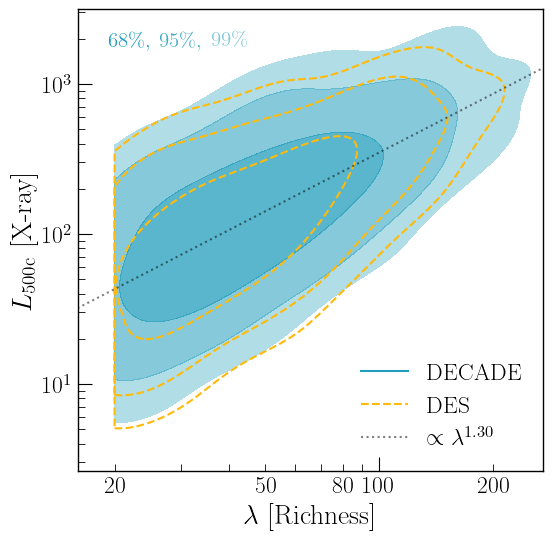

In [6]:
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter

x1, y1 = cata[ind_d_a]['lambda'], eROSITA[ind_e_a]['L500']
x2, y2 = catb[ind_d_b]['lambda'], eROSITA[ind_e_b]['L500']

def density_contour(ax, x, y, label, probs=(0.68, 0.95, 0.99), xcut=20,
                    bw=1.5, smooth=2, alphas=(0.55, 0.85, 1.0), 
                    c_alphas=(0.35, 0.55, 0.75), fill=False, **kwargs):

    m = np.isfinite(x) & np.isfinite(y) & (x >= xcut) & (y > 0)
    x, y = np.log10(x[m]), np.log10(y[m])

    xx = np.linspace(np.log10(xcut), x.max() + 0.10, 400)
    yy = np.linspace(y.min() - 0.15, y.max() + 0.15, 400)
    xx = np.r_[np.log10(xcut) - 1e-4, xx]
    X, Y = np.meshgrid(xx, yy)

    kde = gaussian_kde(np.vstack([x, y]), bw_method=lambda k: bw * k.scotts_factor())
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    Z = gaussian_filter(Z, smooth)

    Z[:, 0] = Z[:, -1] = 0
    Z[0, :] = Z[-1, :] = 0

    s = np.sort(Z.ravel())[::-1]; c = np.cumsum(s) / Z.sum()
    levels = np.sort([s[np.searchsorted(c, p)] for p in probs])

    if fill:
        for lo, hi, alpha in zip(levels, np.r_[levels[1:], Z.max() * 1.001], c_alphas):
            plt.contourf(10**X, 10**Y, Z, levels=[lo, hi], colors=[kwargs['colors']], alpha=alpha, zorder=1)

    for level, alpha in zip(levels, alphas):
        plt.contour(10**X, 10**Y, Z, levels=[level], linewidths=kwargs['lw'],
                    linestyles=kwargs['ls'], colors=kwargs['colors'], alpha=alpha, zorder=2)

    plt.plot([], [], label=label, color=kwargs['colors'], ls=kwargs['ls'])

plt.figure(figsize = (6,6))
density_contour(None, x1, y1, 'DECADE', colors='C1', ls='-',  lw = 0,   fill=True,  alphas = [1.0]*3)
density_contour(None, x2, y2, 'DES',    colors='C2', ls='--', lw = 1.5, fill=False, alphas = [1.0]*3)


from scipy.stats import theilslopes

x = np.r_[x1, x2]; y = np.r_[y1, y2]
m = np.isfinite(x) & np.isfinite(y) & (x >= 20) & (y > 0)

beta, intercept, _, _ = theilslopes(np.log10(y[m]), np.log10(x[m]))
xg = np.geomspace(5, 300, 100); yg = 10**intercept * xg**beta
plt.plot(xg, yg, color='k', lw=1.5, ls = ':', alpha=0.5, zorder=5, label = fr'$\propto\lambda^{{{beta:.2f}}}$')

plt.gca().set(xscale='log', yscale='log')
plt.xlim(16, 270)
# plt.ylim(2e-2, 15)
plt.legend(frameon=False, loc='lower right')
plt.xlabel(r'$\lambda$ [Richness]', size = 20)
plt.ylabel(r'$L_{\rm 500c}$ [X-ray]', size = 20)

from matplotlib.ticker import LogLocator, FuncFormatter

a = plt.gca()
a.xaxis.set_major_locator(LogLocator(base=10, subs=(1,)))
a.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:g}'))
a.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))

labs = {20:'20', 50:'50', 80:'80', 200:'200'}
a.xaxis.set_minor_formatter(FuncFormatter(lambda x, _: labs.get(round(x), '')))


probs    = (0.68, 0.95, 0.99)
c_alphas = (0.55, 0.85, 1.0)

from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, HPacker

items = []
items = [TextArea(fr'${100*p:.0f}\%{"," if i < len(probs)-1 else ""}$',
                  textprops={'color':'C1', 'alpha':alpha, 'size':15})
         for i, (p, alpha) in enumerate(zip(probs, c_alphas[::-1]))]

box = HPacker(children=items, align='center', pad=0, sep=6)
a.add_artist(AnchoredOffsetbox(loc='upper left', child=box, frameon=False, pad=0,
                               bbox_to_anchor=(0.04, 0.98), bbox_transform=a.transAxes))
    
plt.savefig('./XrayScaling.pdf', dpi=300, bbox_inches='tight')

# Check against eROSITA internal richness

In [103]:
X = np.intersect1d(eROSITA['NAME'], eROSITA_opt['NAME'], return_indices = True)
x2, y2 = eROSITA_opt[X[2]]['LAMBDA_OPT_NORM'], eROSITA[X[1]]['L500']

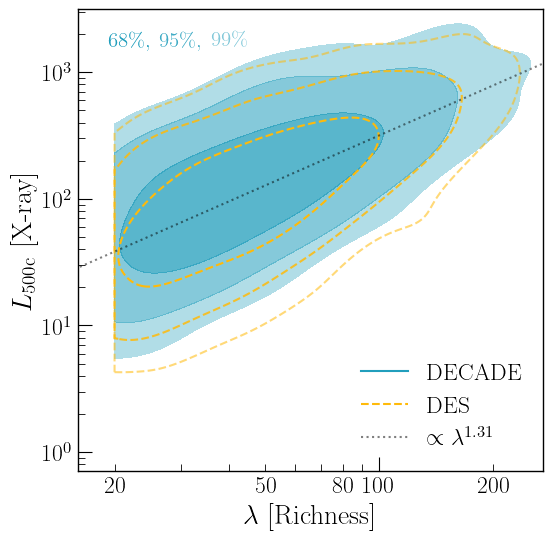

In [104]:
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter

x1, y1 = cata[ind_d_a]['lambda'], eROSITA[ind_e_a]['L500']

def density_contour(ax, x, y, label, probs=(0.68, 0.95, 0.99), xcut=20,
                    bw=1.5, smooth=2, alphas=(0.55, 0.85, 1.0), 
                    c_alphas=(0.35, 0.55, 0.75), fill=False, **kwargs):

    m = np.isfinite(x) & np.isfinite(y) & (x >= xcut) & (y > 0)
    x, y = np.log10(x[m]), np.log10(y[m])

    xx = np.linspace(np.log10(xcut), x.max() + 0.10, 400)
    yy = np.linspace(y.min() - 0.15, y.max() + 0.15, 400)
    xx = np.r_[np.log10(xcut) - 1e-4, xx]
    X, Y = np.meshgrid(xx, yy)

    kde = gaussian_kde(np.vstack([x, y]), bw_method=lambda k: bw * k.scotts_factor())
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    Z = gaussian_filter(Z, smooth)

    Z[:, 0] = Z[:, -1] = 0
    Z[0, :] = Z[-1, :] = 0

    s = np.sort(Z.ravel())[::-1]; c = np.cumsum(s) / Z.sum()
    levels = np.sort([s[np.searchsorted(c, p)] for p in probs])

    if fill:
        for lo, hi, alpha in zip(levels, np.r_[levels[1:], Z.max() * 1.001], c_alphas):
            plt.contourf(10**X, 10**Y, Z, levels=[lo, hi], colors=[kwargs['colors']], alpha=alpha, zorder=1)

    for level, alpha in zip(levels, alphas):
        plt.contour(10**X, 10**Y, Z, levels=[level], linewidths=kwargs['lw'],
                    linestyles=kwargs['ls'], colors=kwargs['colors'], alpha=alpha, zorder=2)

    plt.plot([], [], label=label, color=kwargs['colors'], ls=kwargs['ls'])

plt.figure(figsize = (6,6))
density_contour(ax, x1, y1, 'DECADE', colors='C1', ls='-',  lw = 0,   fill=True)
density_contour(ax, x2, y2, 'DES',    colors='C2', ls='--', lw = 1.5, fill=False)


from scipy.stats import theilslopes

x = np.r_[x1, x2]; y = np.r_[y1, y2]
m = np.isfinite(x) & np.isfinite(y) & (x >= 20) & (y > 0)

beta, intercept, _, _ = theilslopes(np.log10(y[m]), np.log10(x[m]))
xg = np.geomspace(5, 300, 100); yg = 10**intercept * xg**beta
plt.plot(xg, yg, color='k', lw=1.5, ls = ':', alpha=0.5, zorder=5, label = fr'$\propto\lambda^{{{beta:.2f}}}$')

plt.gca().set(xscale='log', yscale='log')
plt.xlim(16, 270)
# plt.ylim(2e-2, 15)
plt.legend(frameon=False, loc='lower right')
plt.xlabel(r'$\lambda$ [Richness]', size = 20)
plt.ylabel(r'$L_{\rm 500c}$ [X-ray]', size = 20)

from matplotlib.ticker import LogLocator, FuncFormatter

a = plt.gca()
a.xaxis.set_major_locator(LogLocator(base=10, subs=(1,)))
a.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:g}'))
a.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))

labs = {20:'20', 50:'50', 80:'80', 200:'200'}
a.xaxis.set_minor_formatter(FuncFormatter(lambda x, _: labs.get(round(x), '')))


probs    = (0.68, 0.95, 0.99)
c_alphas = (0.55, 0.85, 1.0)

from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, HPacker

items = []
items = [TextArea(fr'${100*p:.0f}\%{"," if i < len(probs)-1 else ""}$',
                  textprops={'color':'C1', 'alpha':alpha, 'size':15})
         for i, (p, alpha) in enumerate(zip(probs, c_alphas[::-1]))]

box = HPacker(children=items, align='center', pad=0, sep=6)
a.add_artist(AnchoredOffsetbox(loc='upper left', child=box, frameon=False, pad=0,
                               bbox_to_anchor=(0.04, 0.98), bbox_transform=a.transAxes))